Import the library that will be used

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from keras import Input
from keras.layers import Dense, Reshape, LeakyReLU, Conv2D, Flatten, Dropout
from keras.models import Model
import os
from keras.optimizers import Adam
from keras.layers import UpSampling2D

2025-10-18 23:28:36.579600: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-18 23:28:37.223537: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-18 23:28:39.211100: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Set our directory for the image folder so that the program can access it, count_images will set how many images that we will take from the dataset, set the original width and height, and then set our preference height and width, img_crop so that the image we have will be centered perfectly. Next we will put the images from the dataset into an array that we created, the last step is to do a normalization to our image so it can match the output later which is tanh

In [ ]:
dir = "/home/hartono/projects/CeleBA Image Generator/img_align_celeba"

count_images = 2000

ori_height =  218 
ori_width = 178
dif = (ori_height - ori_width) // 2

width = 64
height = 64

img_crop = (0, dif, ori_width, ori_height - dif)

images = []
for ori_pic in tqdm(os.listdir(dir)[:count_images]):
    path = os.path.join(dir, ori_pic)
    pic = Image.open(path).crop(img_crop)
    pic = pic.resize((width, height), Image.LANCZOS) 
    images.append(np.array(pic))
    
images = np.array(images)

images = (images.astype('float32') - 127.5) / 127.5

print(images.shape)

100%|██████████| 2000/2000 [00:01<00:00, 1057.38it/s]


(2000, 64, 64, 3)


In this code we will try to show some of the images that we've taken from the dataset

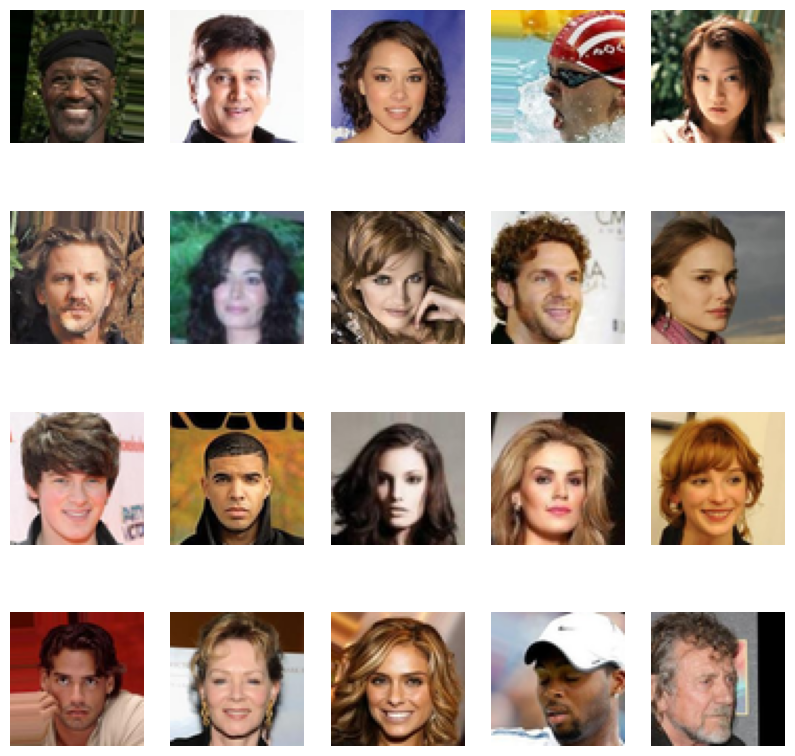

In [3]:
plt.figure(1, figsize=(10, 10))
for i in range(20):
    # Denormalisasi gambar untuk ditampilkan dengan benar
    plt.subplot(4, 5, i+1)
    img_display = (images[i] * 127.5 + 127.5).astype('uint8')
    plt.imshow(img_display)
    plt.axis('off')
plt.show()

Building a generator that will accept the input of 100 random number and set the color to 3 which is RGB, this generator will transform the 100 random number that we input earlier into a 64x64 image

In [ ]:
dimension = 100
color = 3

def create_generator():
    gen_input = Input(shape=(dimension, ))
    
    x = Dense(128 * 8 * 8)(gen_input) 
    x = LeakyReLU(alpha=0.2)(x)
    x = Reshape((8, 8, 128))(x)

    x = UpSampling2D()(x)
    x = Conv2D(256, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = UpSampling2D()(x)
    x = Conv2D(256, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    
    x = UpSampling2D()(x)
    x = Conv2D(256, 5, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    
    x = Conv2D(color, 5, activation='tanh', padding='same')(x)

    generator = Model(gen_input, x, name="generator")
    return generator

After creating the generator we will create the discriminator, the discriminator job here is progressively reducing the image from 64x64 to 8x8 and extracting the complex feature from the images. Basically the discriminator will be trained to differentiate the real and fake images.

In [ ]:
def create_discriminator():
    disc_input = Input(shape=(height, width, color)) 

    x = Conv2D(128, 3)(disc_input)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(128, 4, strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(256, 4, strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Conv2D(256, 4, strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    
    x = Flatten()(x)
    x = Dropout(0.4)(x)

    x = Dense(1, activation='sigmoid')(x)
    discriminator = Model(disc_input, x, name="discriminator")

    optimizer = Adam(learning_rate= 0.0001, beta_1=0.5)
    discriminator.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return discriminator

In this line of code we will create our GAN model which includes generator and discriminator. our model here will have the generator keep improving so that the "generator" model can trick the "discriminator" into believing that the image created by the "generator" is the real image.

In [ ]:
generator = create_generator()
discriminator = create_discriminator()

discriminator.trainable = False

gan_input = Input(shape=(dimension, ))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)

optimizer = Adam(learning_rate= 0.0001, beta_1=0.5)
gan.compile(optimizer=optimizer, loss='binary_crossentropy')

gan.summary()

I0000 00:00:1760804922.899594     796 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
/home/hartono/projects/tf_env/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator (Functional)          │ (None, 64, 64, 3)      │     4,943,363 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Functional)      │ (None, 1)              │     1,855,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,798,980 (25.94 MB)

 Trainable params: 4,943,363 (18.86 MB)

 Non-trainable params: 1,855,617 (7.08 MB)

In our last code, we will train our model 200 times. Here our model the "Discriminator" and "Generator" will be trained, "Discriminator" will be trained every epoch to identify is the image created from the "Generator" real or fake. Our "Generator" in the other hand will keep training so that it can fool the "Discriminator" making it think that the image created by the "Generator" is real, and at the end of the code we will save every 5 images created from this model into our folder so that we can see the results are there any improvement from our model.

In [ ]:
epochs = 200 
batch_size =64

d_losses = []
g_losses = []

seed = np.random.normal(0, 1, size=[batch_size, dimension])

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    
    for i in tqdm(range(images.shape[0] // batch_size)):
        
        real_images = images[i*batch_size : (i+1)*batch_size]
        real_labels = np.ones((batch_size, 1))
        
        noise = np.random.normal(0, 1, size=[batch_size, dimension])
        fake_images = generator.predict(noise)
        fake_labels = np.zeros((batch_size, 1))
        
        x_combined = np.concatenate([real_images, fake_images])
        y_combined = np.concatenate([real_labels, fake_labels])
        
        discriminator.trainable = True
        d_loss = discriminator.train_on_batch(x_combined, y_combined)
        
        noise = np.random.normal(0, 1, size=[batch_size, dimension])
        y_mislabeled = np.ones((batch_size, 1))
        
        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, y_mislabeled)
        
    d_losses.append(d_loss[0])
    g_losses.append(g_loss)
    
    print(f"  Discriminator Loss: {d_loss[0]:.4f}, Accuracy: {d_loss[1]:.2f} | Generator Loss: {g_loss:.4f}")
    
    if (epoch + 1) % 5 == 0:
        generated_images = generator.predict(seed)
        generated_images = 0.5 * generated_images + 0.5 
        
        plt.figure(figsize=(10, 10))
        for j in range(16): 
            plt.subplot(4, 4, j+1)
            plt.imshow(generated_images[j])
            plt.axis('off')
        plt.tight_layout()
        plt.savefig(f'gan_generated_image_epoch_{epoch+1}.png')
        plt.close() 
        
        generator.save_weights(f'generator_epoch_{epoch+1}.weights.h5')

print('Pelatihan Selesai')

Epoch 1/200


  0%|          | 0/31 [00:00<?, ?it/s]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  3%|▎         | 1/31 [00:03<01:47,  3.59s/it]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


...

 97%|█████████▋| 30/31 [00:19<00:00,  1.82it/s]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


100%|██████████| 31/31 [00:20<00:00,  1.54it/s]

  Discriminator Loss: 0.3907, Accuracy: 0.83 | Generator Loss: 1.9534
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


Pelatihan Selesai
